# Quantum Random Access Optimization (QRAO) and Pauli Correlation Encoding (PCE) for Phylogenetic Trees

---

In this notebook, we are going to use Qiskit to solve the needed optimization problem to reconstruct Phylogenetic Trees. This work will be based in 3 documents, the qiskit tutorials for QRAO and PCE [1,2], and the paper for reconstruction of Phylogenetic Trees [2].



[1] Qiskit Community. (2026). Quantum Random Access Optimization. Qiskit Optimization. https://qiskit-community.github.io/qiskit-optimization/tutorials/12_quantum_random_access_optimizer.html

[2] IBM. (2026). Pauli correlation encoding to reduce max-cut requirements. IBM Quantum Documentation. https://quantum.cloud.ibm.com/docs/en/tutorials/pauli-correlation-encoding-for-qaoa

[3] Onodera, W., Hara, N., Aoki, S., Asahi, T., & Sawamura, N. (2022). Phylogenetic tree reconstruction via graph cut presented using a quantum-inspired computer. Molecular Phylogenetics and Evolution, 178, 107636. https://doi.org/10.1016/j.ympev.2022.107636

In [1]:
from qa_functions import *
from qaoa_functions import *
import time
import re
from qiskit.visualization import plot_histogram
import os
from qiskit_optimization.algorithms.qrao import (
    QuantumRandomAccessEncoding,
    QuantumRandomAccessOptimizer,
    SemideterministicRounding,
)
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.circuit.library import efficient_su2

# QRAO

Problem name: Max-cut

Maximize
  -2*x_0*x_1 - 2*x_0*x_3 - 2*x_0*x_4 - 2*x_1*x_2 - 2*x_1*x_5 - 2*x_2*x_3
  - 2*x_2*x_4 - 2*x_3*x_5 - 2*x_4*x_5 + 3*x_0 + 3*x_1 + 3*x_2 + 3*x_3 + 3*x_4
  + 3*x_5

Subject to
  No constraints

  Binary variables (6)
    x_0 x_1 x_2 x_3 x_4 x_5



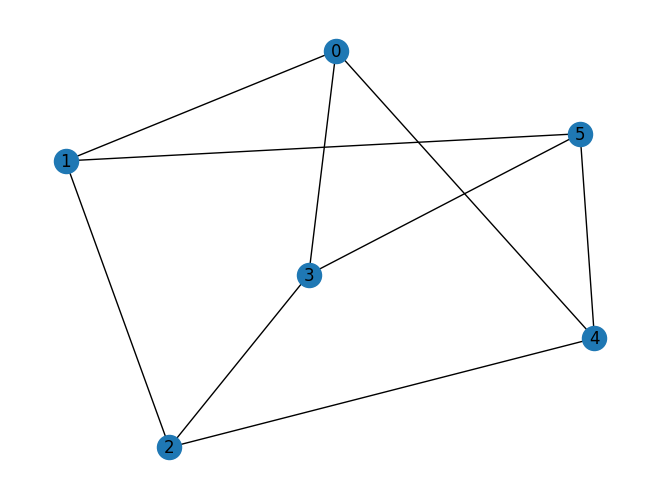

In [2]:
import networkx as nx
from qiskit_optimization.applications import Maxcut

seed = 1
num_nodes = 6
graph = nx.random_regular_graph(d=3, n=num_nodes, seed=seed)
nx.draw(graph, with_labels=True, pos=nx.spring_layout(graph, seed=seed))

maxcut = Maxcut(graph)
problem = maxcut.to_quadratic_program()
print(problem.prettyprint())

In [3]:
# Create an encoding object with a maximum of 3 variables per qubit, aka a (3,1,p)-QRAC
encoding = QuantumRandomAccessEncoding(max_vars_per_qubit=3)

# Encode the QUBO problem into an encoded Hamiltonian
encoding.encode(problem)

# This is our encoded Hamiltonian
print(f"Our encoded Hamiltonian is:\n( {encoding.qubit_op} ).\n")
print(
    "We achieve a compression ratio of "
    f"({encoding.num_vars} binary variables : {encoding.num_qubits} qubits) "
    f"≈ {encoding.compression_ratio}.\n"
)

Our encoded Hamiltonian is:
( SparsePauliOp(['XX', 'XY', 'XZ', 'YX', 'ZX', 'YY', 'YZ', 'ZY', 'ZZ'],
              coeffs=[1.5+0.j, 1.5+0.j, 1.5+0.j, 1.5+0.j, 1.5+0.j, 1.5+0.j, 1.5+0.j, 1.5+0.j,
 1.5+0.j]) ).

We achieve a compression ratio of (6 binary variables : 2 qubits) ≈ 3.0.



In [7]:
from qiskit.circuit.library import real_amplitudes
from qiskit.primitives import StatevectorEstimator
from qiskit_optimization.minimum_eigensolvers import VQE
from qiskit_optimization.optimizers import COBYLA

# Prepare the VQE algorithm
ansatz = real_amplitudes(2)
vqe = VQE(
    ansatz=ansatz,
    optimizer=COBYLA(),
    estimator=StatevectorEstimator(),
)

# Use semi-deterministic rounding, known as "Pauli rounding"
# in https://arxiv.org/pdf/2111.03167v2.pdf
# (This is the default if no rounding scheme is specified.)
semidterministic_rounding = SemideterministicRounding()

# Construct the optimizer
qrao = QuantumRandomAccessOptimizer(min_eigen_solver=vqe, rounding_scheme=semidterministic_rounding)

results = qrao.solve(problem)

print(
    f"The objective function value: {results.fval}\n"
    f"x: {results.x}\n"
    f"relaxed function value: {-1 * results.relaxed_fval}\n"
)

The objective function value: 5.0
x: [1 0 0 1 1 0]
relaxed function value: 8.999999996061959



The obtained solution places a partition between nodes [1, 2, 5] and nodes [0, 3, 4].


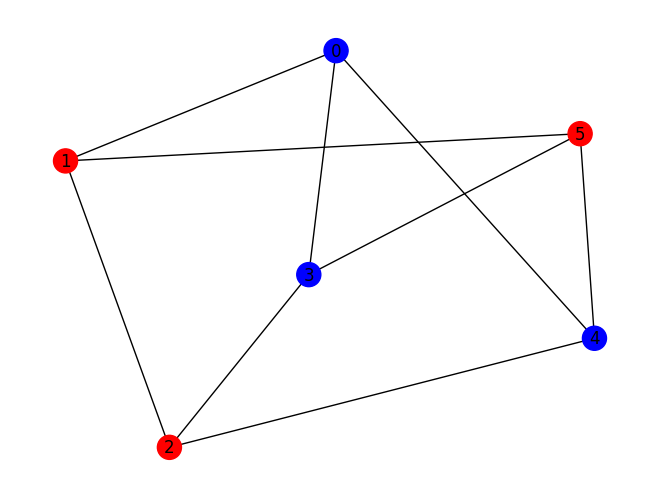

In [8]:
maxcut_partition = maxcut.interpret(results)
print(
    f"The obtained solution places a partition between nodes {maxcut_partition[0]} "
    f"and nodes {maxcut_partition[1]}."
)
maxcut.draw(results, pos=nx.spring_layout(graph, seed=seed))

## Now with our quadratic problem

In [25]:
matrix = np.array( [[ 0, 92, 73, 78, 92],
                    [92,  0, 21, 49, 34],
                    [73, 21,  0, 35, 63],
                    [78, 49, 35,  0, 29],
                    [92, 34, 63, 29,  0]])

# matrix = np.array([[  0.,   4.,  70.,  88.,  30.,  36.,  23.,   5.,  72.,  36.],
#        [  4.,   0.,  33.,  89.,   9.,  23.,  18.,   9.,  60.,  79.],
#        [ 70.,  33.,   0.,  36.,  15., 100.,   7.,  14.,  10.,  18.],
#        [ 88.,  89.,  36.,   0.,   6.,  35.,  69.,  96.,  67.,  15.],
#        [ 30.,   9.,  15.,   6.,   0.,  66.,  54.,  45.,  77.,  49.],
#        [ 36.,  23., 100.,  35.,  66.,   0.,  93.,   3.,  75.,  84.],
#        [ 23.,  18.,   7.,  69.,  54.,  93.,   0.,   2.,  43.,   1.],
#        [  5.,   9.,  14.,  96.,  45.,   3.,   2.,   0.,   6.,  86.],
#        [ 72.,  60.,  10.,  67.,  77.,  75.,  43.,   6.,   0.,  95.],
#        [ 36.,  79.,  18.,  15.,  49.,  84.,   1.,  86.,  95.,   0.]])

problem = min_cut_c(matrix,c=1,alpha=500)
print(problem)

BinaryQuadraticModel({1: -304.0, 0: -165.0, 2: -308.0, 3: -309.0, 4: -282.0}, {(0, 1): 816.0, (2, 1): 958.0, (2, 0): 854.0, (3, 1): 902.0, (3, 0): 844.0, (3, 2): 930.0, (4, 1): 932.0, (4, 0): 816.0, (4, 2): 874.0, (4, 3): 942.0}, 500.0, 'BINARY')


In [26]:
qp = bqm_to_quadratic_program(problem)

print(qp.prettyprint())

Problem name: 

Minimize
  854*0*2 + 844*0*3 + 816*0*4 + 816*1*0 + 958*1*2 + 902*1*3 + 932*1*4 + 930*2*3
  + 874*2*4 + 942*3*4 - 165*0 - 304*1 - 308*2 - 309*3 - 282*4 + 500

Subject to
  No constraints

  Binary variables (5)
    1 0 2 3 4



We can see that our ocean-based min cut generated problem and the Qiskit optimization quadratic problem are defining the same Quadratic optimization problem. Thus, we can use this direct transformation to obtain a QRAO.

In [27]:
# Create an encoding object with a maximum of 3 variables per qubit, aka a (3,1,p)-QRAC
encoding = QuantumRandomAccessEncoding(max_vars_per_qubit=3)

# Encode the QUBO problem into an encoded Hamiltonian
encoding.encode(qp)

# This is our encoded Hamiltonian
print(f"Our encoded Hamiltonian is:\n( {encoding.qubit_op} ).\n")
print(
    "We achieve a compression ratio of "
    f"({encoding.num_vars} binary variables : {encoding.num_qubits} qubits) "
    f"≈ {encoding.compression_ratio}.\n"
)

Our encoded Hamiltonian is:
( SparsePauliOp(['XIIII', 'IXIII', 'IIXII', 'IIIXI', 'IIIIX', 'XXIII', 'XIXII', 'XIIXI', 'XIIIX', 'IXXII', 'IXIXI', 'IXIIX', 'IIXXI', 'IIXIX', 'IIIXX'],
              coeffs=[-1299.03810568+0.j, -1299.03810568+0.j, -1299.03810568+0.j,
 -1299.03810568+0.j, -1299.03810568+0.j,   612.        +0.j,
   718.5       +0.j,   676.5       +0.j,   699.        +0.j,
   640.5       +0.j,   633.        +0.j,   612.        +0.j,
   697.5       +0.j,   655.5       +0.j,   706.5       +0.j]) ).

We achieve a compression ratio of (5 binary variables : 5 qubits) ≈ 1.0.



We find out that using a fully connected graph (like the ones that we currently use) results in having no reduction in the number of total qubits. This is because two variables that share a quadratic term in the objective cannot be placed on the same qubit.

One solution for this problem is to sparsifying the similarity graph. What this means is to zero out the edges whose weights are so small they only add noise for the classification. There are multiple ways to sparsify a matrix, but we define 4 methods:
* Otsu
* Percentile
* Zscore
* Knee

Using this methods, the number of qubits needed could be reduced.

In [28]:
import numpy as np
from scipy import stats

def threshold_similarity_matrix(W: np.ndarray, method: str = "otsu") -> tuple[np.ndarray, float]:
    """
    Sparsify a similarity matrix by zeroing out edges below a data-driven threshold.
    
    Args:
        W:      Symmetric similarity matrix (NxN), diagonal ignored.
        method: One of "otsu", "percentile", "zscore", "knee"
    
    Returns:
        W_sparse: Thresholded matrix
        threshold: The threshold value used
    """
    # Extract upper-triangle values (avoid diagonal and duplicate edges)
    idx = np.triu_indices_from(W, k=1)
    weights = W[idx]

    if method == "otsu":
        threshold = _otsu_threshold(weights)

    elif method == "percentile":
        # Keep the top 50% of edges by default — adjust as needed
        threshold = np.percentile(weights, 50)

    elif method == "zscore":
        # Zero out anything more than 1 std below the mean
        threshold = weights.mean() - weights.std()

    elif method == "knee":
        threshold = _knee_threshold(weights)

    else:
        raise ValueError(f"Unknown method: {method}")

    # Apply threshold symmetrically
    W_sparse = W.copy()
    W_sparse[W_sparse < threshold] = 0
    np.fill_diagonal(W_sparse, 0)  # Nodes don't connect to themselves in QRAO
    return W_sparse, threshold


def _otsu_threshold(values: np.ndarray) -> float:
    """
    Otsu's method: finds the threshold that minimises intra-class variance.
    Works well when similarity values are bimodal (a cluster of weak edges
    and a cluster of strong edges).
    """
    bins = 256
    counts, bin_edges = np.histogram(values, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    total = counts.sum()

    best_thresh, best_var = 0, -1
    w0_sum = 0
    mu0_sum = 0

    for i in range(1, bins):
        w0 = counts[:i].sum() / total
        w1 = 1 - w0
        if w0 == 0 or w1 == 0:
            continue
        mu0 = (counts[:i] * bin_centers[:i]).sum() / (counts[:i].sum() + 1e-12)
        mu1 = (counts[i:] * bin_centers[i:]).sum() / (counts[i:].sum() + 1e-12)
        between_var = w0 * w1 * (mu0 - mu1) ** 2
        if between_var > best_var:
            best_var = between_var
            best_thresh = bin_centers[i]

    return best_thresh


def _knee_threshold(values: np.ndarray) -> float:
    """
    Knee/elbow detection on the sorted weight curve.
    Finds where the curve bends — a natural 'drop-off' point.
    """
    sorted_vals = np.sort(values)[::-1]  # Descending
    n = len(sorted_vals)
    x = np.linspace(0, 1, n)

    # Normalise
    y = (sorted_vals - sorted_vals.min()) / (sorted_vals.max() - sorted_vals.min() + 1e-12)

    # Distance from each point to the line connecting first and last
    line_vec = np.array([x[-1] - x[0], y[-1] - y[0]])
    line_vec /= np.linalg.norm(line_vec)
    point_vecs = np.stack([x - x[0], y - y[0]], axis=1)
    distances = np.abs(np.cross(line_vec, point_vecs))
    knee_idx = np.argmax(distances)

    return sorted_vals[knee_idx]

In [38]:
matrix = np.array( [[ 0, 92, 73, 78, 92],
                    [92,  0, 21, 49, 34],
                    [73, 21,  0, 35, 63],
                    [78, 49, 35,  0, 29],
                    [92, 34, 63, 29,  0]])

# matrix = np.array([[  0.,   4.,  70.,  88.,  30.,  36.,  23.,   5.,  72.,  36.],
#        [  4.,   0.,  33.,  89.,   9.,  23.,  18.,   9.,  60.,  79.],
#        [ 70.,  33.,   0.,  36.,  15., 100.,   7.,  14.,  10.,  18.],
#        [ 88.,  89.,  36.,   0.,   6.,  35.,  69.,  96.,  67.,  15.],
#        [ 30.,   9.,  15.,   6.,   0.,  66.,  54.,  45.,  77.,  49.],
#        [ 36.,  23., 100.,  35.,  66.,   0.,  93.,   3.,  75.,  84.],
#        [ 23.,  18.,   7.,  69.,  54.,  93.,   0.,   2.,  43.,   1.],
#        [  5.,   9.,  14.,  96.,  45.,   3.,   2.,   0.,   6.,  86.],
#        [ 72.,  60.,  10.,  67.,  77.,  75.,  43.,   6.,   0.,  95.],
#        [ 36.,  79.,  18.,  15.,  49.,  84.,   1.,  86.,  95.,   0.]])

G = nx.from_numpy_array(matrix)
og_num_edges = G.number_of_edges()

print(f"Original number of edges: {og_num_edges}")
print("="*60)

for method in ["otsu", "percentile", "zscore", "knee"]:
    W_sparse, thresh = threshold_similarity_matrix(matrix, method=method)
    G = nx.from_numpy_array(W_sparse)
    num_edges = G.number_of_edges()
    
    print(f"{method:12s} | threshold={thresh:.4f} | num_edges={num_edges} | compression={1-num_edges/og_num_edges:.3f}")

    problem = min_cut_c(W_sparse,c=1,alpha=500)
    qp = bqm_to_quadratic_program(problem)
    print(qp.prettyprint())
    print(W_sparse)
    
    encoding = QuantumRandomAccessEncoding(max_vars_per_qubit=3)
    encoding.encode(qp)
    print(f"Compression: {encoding.num_vars} vars → {encoding.num_qubits} qubits "
      f"(ratio {encoding.compression_ratio:.2f}x)")

Original number of edges: 10
otsu         | threshold=49.1504 | num_edges=5 | compression=0.500
Problem name: 

Minimize
  854*0*2 + 844*0*3 + 816*0*4 + 816*1*0 + 1000*1*2 + 1000*1*3 + 1000*1*4
  + 1000*2*3 + 874*2*4 + 1000*3*4 - 165*0 - 408*1 - 364*2 - 422*3 - 345*4 + 500

Subject to
  No constraints

  Binary variables (5)
    1 0 2 3 4

[[ 0 92 73 78 92]
 [92  0  0  0  0]
 [73  0  0  0 63]
 [78  0  0  0  0]
 [92  0 63  0  0]]
Compression: 5 vars → 5 qubits (ratio 1.00x)
percentile   | threshold=56.0000 | num_edges=5 | compression=0.500
Problem name: 

Minimize
  854*0*2 + 844*0*3 + 816*0*4 + 816*1*0 + 1000*1*2 + 1000*1*3 + 1000*1*4
  + 1000*2*3 + 874*2*4 + 1000*3*4 - 165*0 - 408*1 - 364*2 - 422*3 - 345*4 + 500

Subject to
  No constraints

  Binary variables (5)
    1 0 2 3 4

[[ 0 92 73 78 92]
 [92  0  0  0  0]
 [73  0  0  0 63]
 [78  0  0  0  0]
 [92  0 63  0  0]]
Compression: 5 vars → 5 qubits (ratio 1.00x)
zscore       | threshold=31.4238 | num_edges=8 | compression=0.200
Proble

C:\Users\nicolas.fernandez\AppData\Local\Temp\ipykernel_11960\210533607.py:90: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distances = np.abs(np.cross(line_vec, point_vecs))


In [51]:
print(W_sparse)
c = 1
alpha = 500

def min_cut_qp(matrix: np.ndarray, tags=[]) -> QuadraticProgram:
    r"""
    Creates a QuadraticProgram from a numpy matrix using the Min-cut formulation.
    Both symmetrical matrices and matrices with 0 above the main diagonal work.

    Objective (minimise):
        sum_{i>j} w_ij * (x_i - x_j)^2
        = sum_{i>j} w_ij * (x_i + x_j - 2*x_i*x_j)    [since x_i^2 = x_i for binary]

    Args:
        matrix: NxN weight matrix defining the problem.
        tags:   Optional variable names. Defaults to "0", "1", ..., "N-1".

    Returns:
        QuadraticProgram encoding the min-cut objective.
    """
    rows = matrix.shape[0]
    qp = QuadraticProgram()

    var_names = [str(t) for t in tags] if tags else [str(i) for i in range(rows)]

    for name in var_names:
        qp.binary_var(name)

    linear = {}
    quadratic = {}

    for i in range(rows):
        for j in range(i):          # lower triangle only — handles both symmetric
            w = matrix[i, j]        # and upper-triangle-zero matrices correctly
            if w == 0:
                continue

            # Linear part: w*(x_i + x_j)
            linear[var_names[i]] = linear.get(var_names[i], 0) + w
            linear[var_names[j]] = linear.get(var_names[j], 0) + w

            # Quadratic part: -2w * x_i * x_j
            key = (var_names[i], var_names[j])
            quadratic[key] = quadratic.get(key, 0) - 2 * w

    qp.minimize(linear=linear, quadratic=quadratic)
    return qp

print(min_cut_qp(W_sparse).prettyprint())

[[ 0 92 73 78 92]
 [92  0  0 49  0]
 [73  0  0 35 63]
 [78 49 35  0  0]
 [92  0 63  0  0]]
Problem name: 

Minimize
  -184*0*1 - 146*0*2 - 156*0*3 - 184*0*4 - 98*1*3 - 70*2*3 - 126*2*4 + 335*0
  + 141*1 + 171*2 + 162*3 + 155*4

Subject to
  No constraints

  Binary variables (5)
    0 1 2 3 4



In [53]:
matrix = np.array( [[ 0, 92, 73, 78, 92],
                    [92,  0, 21, 49, 34],
                    [73, 21,  0, 35, 63],
                    [78, 49, 35,  0, 29],
                    [92, 34, 63, 29,  0]])

# matrix = np.array([[  0.,   4.,  70.,  88.,  30.,  36.,  23.,   5.,  72.,  36.],
#        [  4.,   0.,  33.,  89.,   9.,  23.,  18.,   9.,  60.,  79.],
#        [ 70.,  33.,   0.,  36.,  15., 100.,   7.,  14.,  10.,  18.],
#        [ 88.,  89.,  36.,   0.,   6.,  35.,  69.,  96.,  67.,  15.],
#        [ 30.,   9.,  15.,   6.,   0.,  66.,  54.,  45.,  77.,  49.],
#        [ 36.,  23., 100.,  35.,  66.,   0.,  93.,   3.,  75.,  84.],
#        [ 23.,  18.,   7.,  69.,  54.,  93.,   0.,   2.,  43.,   1.],
#        [  5.,   9.,  14.,  96.,  45.,   3.,   2.,   0.,   6.,  86.],
#        [ 72.,  60.,  10.,  67.,  77.,  75.,  43.,   6.,   0.,  95.],
#        [ 36.,  79.,  18.,  15.,  49.,  84.,   1.,  86.,  95.,   0.]])

G = nx.from_numpy_array(matrix)
og_num_edges = G.number_of_edges()

print(f"Original number of edges: {og_num_edges}")
print("="*60)

for method in ["otsu", "percentile", "zscore", "knee"]:
    W_sparse, thresh = threshold_similarity_matrix(matrix, method=method)
    G = nx.from_numpy_array(W_sparse)
    num_edges = G.number_of_edges()
    
    print(f"{method:12s} | threshold={thresh:.4f} | num_edges={num_edges} | compression={1-num_edges/og_num_edges:.3f}")

    qp = min_cut_qp(W_sparse)
    
    encoding = QuantumRandomAccessEncoding(max_vars_per_qubit=3)
    encoding.encode(qp)
    print(f"Compression: {encoding.num_vars} vars → {encoding.num_qubits} qubits "
      f"(ratio {encoding.compression_ratio:.2f}x)")

Original number of edges: 10
otsu         | threshold=49.1504 | num_edges=5 | compression=0.500
Compression: 5 vars → 3 qubits (ratio 1.67x)
percentile   | threshold=56.0000 | num_edges=5 | compression=0.500
Compression: 5 vars → 3 qubits (ratio 1.67x)
zscore       | threshold=31.4238 | num_edges=8 | compression=0.200
Compression: 5 vars → 3 qubits (ratio 1.67x)
knee         | threshold=35.0000 | num_edges=7 | compression=0.300
Compression: 5 vars → 3 qubits (ratio 1.67x)


C:\Users\nicolas.fernandez\AppData\Local\Temp\ipykernel_11960\210533607.py:90: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  distances = np.abs(np.cross(line_vec, point_vecs))


In [56]:
W_sparse, thresh = threshold_similarity_matrix(matrix, method="zscore")

qp = min_cut_qp(W_sparse)

encoding = QuantumRandomAccessEncoding(max_vars_per_qubit=3)
encoding.encode(qp)
print(f"Our encoded Hamiltonian is:\n( {encoding.qubit_op} ).\n")
print(
    "We achieve a compression ratio of "
    f"({encoding.num_vars} binary variables : {encoding.num_qubits} qubits) "
    f"≈ {encoding.compression_ratio:.2f}.\n"
)

Our encoded Hamiltonian is:
( SparsePauliOp(['XXI', 'XYI', 'XIX', 'XIY', 'IXX', 'IXY', 'IYX', 'IYY'],
              coeffs=[-138. +0.j, -109.5+0.j, -117. +0.j, -138. +0.j,  -73.5+0.j,  -51. +0.j,
  -52.5+0.j,  -94.5+0.j]) ).

We achieve a compression ratio of (5 binary variables : 3 qubits) ≈ 1.67.



In [94]:
import numpy as np
from qiskit.circuit.library import real_amplitudes
from qiskit.primitives import StatevectorEstimator, StatevectorSampler
from qiskit_optimization.problems import QuadraticProgram
from qiskit_optimization.algorithms.qrao import (
    QuantumRandomAccessEncoding,
    QuantumRandomAccessOptimizer,
    MagicRounding,
    SemideterministicRounding,
)
from qiskit_optimization.minimum_eigensolvers import VQE
from qiskit_optimization.optimizers import COBYLA


# ── helpers ────────────────────────────────────────────────────────────────────

def _eval(qp: QuadraticProgram, x: np.ndarray) -> float:
    """Evaluate the QP objective at a binary vector."""
    return qp.objective.evaluate(x)


def _project_to_cardinality(
    x: np.ndarray, c: int, qp: QuadraticProgram
) -> tuple[np.ndarray, float]:
    """
    Greedily flip bits one at a time until exactly c are 1,
    choosing each flip to keep the objective as low as possible.
    """
    x = x.copy().astype(float)

    while int(x.sum()) != c:
        excess = int(x.sum()) - c          # positive → too many 1s
        candidates = np.where(x == (1 if excess > 0 else 0))[0]
        target_value = 0.0 if excess > 0 else 1.0

        best_idx = min(
            candidates,
            key=lambda idx: _eval(qp, np.where(
                np.arange(len(x)) == idx, target_value, x
            )),
        )
        x[best_idx] = target_value

    return x, _eval(qp, x)


def _best_with_cardinality(
    samples, c: int, qp: QuadraticProgram
) -> tuple[np.ndarray, float]:
    """
    Return the best solution with exactly c ones.

    Strategy:
      1. Filter samples that already satisfy the constraint → pick best fval.
      2. If none exist, project every sample to cardinality c and pick best.
    """
    feasible = [s for s in samples if int(s.x.sum()) == c]

    if feasible:
        best = min(feasible, key=lambda s: s.fval)   # minimisation → lowest fval
        return best.x.copy().astype(float), float(best.fval)

    # No sample satisfies the constraint: project all and keep the best
    best_x, best_fval = None, float("inf")
    for sample in samples:
        x_proj, fval = _project_to_cardinality(sample.x, c, qp)
        if fval < best_fval:
            best_fval = fval
            best_x = x_proj

    return best_x, best_fval


# ── main function ──────────────────────────────────────────────────────────────

def run_qrao_min_cut(
    matrix: np.ndarray,
    c: int,
    sparsity_method = "zscore", # "zscore" | "otsu" | "knee" | "percentile"
    tags: list = [],
    max_vars_per_qubit: int = 3,
    rounding: str = "magic",   # "magic" | "semideterministic"
    shots: int = 10_000,
    seed: int = 42,
) -> dict:
    """
    Solve a min-cut problem with QRAO, post-processing the result
    to enforce exactly c variables equal to 1.

    Args:
        matrix:             NxN weight matrix (symmetric or lower-triangle).
        c:                  Required number of selected assets (ones in solution).
        tags:               Optional variable names; defaults to "0".."N-1".
        max_vars_per_qubit: QRAC compression level (1, 2, or 3).
        rounding:           "magic" (multiple samples) or "semideterministic".
        shots:              Number of magic rounding shots.
        seed:               RNG seed for reproducibility.

    Returns:
        dict with keys:
            x                — binary solution array with exactly c ones
            fval             — objective value at x
            raw_result       — full QuantumRandomAccessOptimizationResult
            num_qubits       — qubits used after compression
            compression_ratio
            feasible_found   — whether any sample satisfied the constraint directly
    """
    # ── 1. Sparsify the matrix and build the QUBO ──────────────────────────────────────────────────────
    W_sparse,thresh = threshold_similarity_matrix(matrix, method=sparsity_method)
    
    qp = min_cut_qp(W_sparse,tags)

    # ── 2. Encode ──────────────────────────────────────────────────────────────
    encoding = QuantumRandomAccessEncoding(max_vars_per_qubit=max_vars_per_qubit)
    encoding.encode(qp)
    # print(
    #     f"Encoding: {encoding.num_vars} variables → {encoding.num_qubits} qubits "
    #     f"(compression {encoding.compression_ratio:.2f}x)"
    # )

    # ── 3. Solver (VQE) ────────────────────────────────────────────────────────
    pm = generate_preset_pass_manager(optimization_level=3, backend=AerSimulator())
    estimator = AerEstimator(
                        options={
                            "backend_options": {
                                "method": "statevector",   # exact simulation — same as StatevectorEstimator
                                "device": "CPU",           # swap to "GPU" if you have a CUDA-capable card
                                "max_parallel_threads": 0, # 0 = use all available cores
                                "max_parallel_experiments":0
                            }
                        }
)
    ansatz = real_amplitudes(encoding.num_qubits)
    vqe = VQE(ansatz=ansatz, optimizer=COBYLA(maxiter=300), estimator=estimator, pass_manager= pm)

    # ── 4. Rounding scheme ─────────────────────────────────────────────────────
    if rounding == "magic":
        sampler = AerSampler(
                    options={
                        "backend_options": {
                            "method": "statevector",           # swap to "GPU" if you have a CUDA-capable card
                                "max_parallel_threads": 0, # 0 = use all available cores
                                "max_parallel_experiments":0
                        }
                    }
                )
        rounding_scheme = MagicRounding(sampler=sampler, pass_manager=pm)
    elif rounding == "semideterministic":
        rounding_scheme = SemideterministicRounding()
    else:
        raise ValueError(f"Unknown rounding '{rounding}'. Use 'magic' or 'semideterministic'.")

    # ── 5. Solve ───────────────────────────────────────────────────────────────
    qrao = QuantumRandomAccessOptimizer(
        min_eigen_solver=vqe,
        rounding_scheme=rounding_scheme,
    )
    raw_result = qrao.solve(qp)

    # ── 6. Post-process: enforce exactly c ones ────────────────────────────────
    feasible_found = any(int(s.x.sum()) == c for s in raw_result.samples)
    x, fval = _best_with_cardinality(raw_result.samples, c, qp)

    if not feasible_found:
        print(
            f"No sample had exactly {c} ones — "
            f"projected best sample to cardinality {c}."
        )

    return {
        "x":                  x,
        "fval":               fval,
        "raw_result":         raw_result,
        "num_qubits":         encoding.num_qubits,
        "compression_ratio":  encoding.compression_ratio,
        "feasible_found":     feasible_found,
    }
    
matrix = np.array([[  0.,   4.,  70.,  88.,  30.,  36.,  23.,   5.,  72.,  36.],
       [  4.,   0.,  33.,  89.,   9.,  23.,  18.,   9.,  60.,  79.],
       [ 70.,  33.,   0.,  36.,  15., 100.,   7.,  14.,  10.,  18.],
       [ 88.,  89.,  36.,   0.,   6.,  35.,  69.,  96.,  67.,  15.],
       [ 30.,   9.,  15.,   6.,   0.,  66.,  54.,  45.,  77.,  49.],
       [ 36.,  23., 100.,  35.,  66.,   0.,  93.,   3.,  75.,  84.],
       [ 23.,  18.,   7.,  69.,  54.,  93.,   0.,   2.,  43.,   1.],
       [  5.,   9.,  14.,  96.,  45.,   3.,   2.,   0.,   6.,  86.],
       [ 72.,  60.,  10.,  67.,  77.,  75.,  43.,   6.,   0.,  95.],
       [ 36.,  79.,  18.,  15.,  49.,  84.,   1.,  86.,  95.,   0.]])   

result = run_qrao_min_cut(matrix, c=2, rounding="magic", shots=10_000)

print(f"Selected assets: {np.where(result['x'] == 1)[0].tolist()}")
print(f"Objective value: {result['fval']:.4f}")
print(f"Qubits used:     {result['num_qubits']} ({result['compression_ratio']:.2f}x compression)")
print(f"Cardinality met by a raw sample: {result['feasible_found']}")

Selected assets: [4, 7]
Objective value: 487.0000
Qubits used:     5 (2.00x compression)
Cardinality met by a raw sample: True


In [84]:
def qrao_phylo_tree_qiskit(matrix:np.ndarray,tags=[],backend=AerSimulator(),**kwargs):
    r"""
    Recursive function that uses QRAO to create the Phylogenetic tree using Ncut
    
    Args:
        `matrix`: The matrix defining the graph.
        `tags`: Tags defining the names of the nodes, used for recursivity. **MUST BE AN INT LIST**
    Returns:
        The `TreeNode` containing the full tree. 
    """
    ncuts = []
    
    if not tags:
        sub_mat = matrix
        tags = list(range(matrix.shape[0]))
    else:
        sub_mat = matrix[np.ix_(tags, tags)]
        
    rows = sub_mat.shape[0]
    
    var = int(np.floor(rows/2.0))+1
    
    while not ncuts:
        
        n_graph_0 = []
        n_graph_1 = []
        # Run min_cut for each configuration
        for i in range(1,var):
            # print(f'Corte con {i}')
            if 'timer' in kwargs:
                start = time.time_ns()/1000000
            # Prepare the expression and run the QRAO    
            res = run_qrao_min_cut(sub_mat,c = i)
            
            result = [str(int(x)) for x in res['x']]
            minim = res['fval']
                    
            # Time measurement
            if 'timer' in kwargs:
                end = time.time_ns()/1000000
                kwargs['timer'].update(end-start)
                
            n_graph_0.append([tags[j] for j in range(len(result)) if result[j]=='0'])
            n_graph_1.append([tags[j] for j in range(len(result)) if result[j]=='1'])        
            # print(f'\tLa division es: {n_graph_0[i-1]} | {n_graph_1[i-1]}')
            
            # print(n_cut(minim,n_graph_0[i-1],n_graph_1[i-1],matrix))
            
            if n_graph_0[i-1] and n_graph_1[i-1]:
                ncuts.append(n_cut(minim,n_graph_0[i-1],n_graph_1[i-1],matrix))
                
    
    # Get the cuts created by the minimum ncut value
    index = np.argmin(ncuts)
    # print(f'Se selecciona la separacion: {n_graph_0[index]} | {n_graph_1[index]}')
    
    node = TreeNode(tags)
    
    # Recursivity in the first graph
    if len(n_graph_0[index]) > 2:
        if 'timer' in kwargs:
            node.children.append(qrao_phylo_tree_qiskit(matrix,tags=n_graph_0[index],backend=backend,timer=kwargs['timer']))
        else:
            node.children.append(qrao_phylo_tree_qiskit(matrix,tags=n_graph_0[index],backend=backend,))
    else:
        leaf = TreeNode(n_graph_0[index])
        if len(n_graph_0[index]) == 2:
            leaf.children.append(TreeNode([n_graph_0[index][0]]))
            leaf.children.append(TreeNode([n_graph_0[index][1]]))
        node.children.append(leaf)
        
    # Recursivity in the first graph
    if len(n_graph_1[index]) > 2:
        if 'timer' in kwargs:
            node.children.append(qrao_phylo_tree_qiskit(matrix,tags=n_graph_1[index],backend=backend,timer=kwargs['timer']))
        else:
            node.children.append(qrao_phylo_tree_qiskit(matrix,tags=n_graph_1[index],backend=backend,))
    else:
        leaf = TreeNode(n_graph_1[index])
        if len(n_graph_1[index]) == 2:
            leaf.children.append(TreeNode([n_graph_1[index][0]]))
            leaf.children.append(TreeNode([n_graph_1[index][1]]))
        node.children.append(leaf)
    
    return node

Tree done in 40727.2122ms


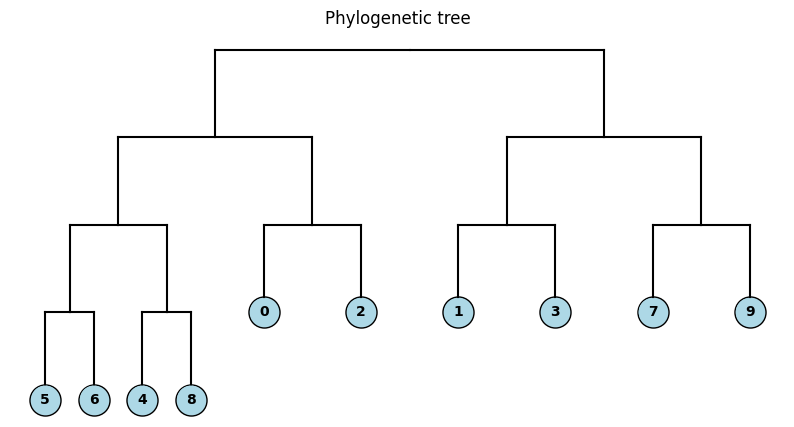

In [92]:
matrix = np.array([[  0.,   4.,  70.,  88.,  30.,  36.,  23.,   5.,  72.,  36.],
       [  4.,   0.,  33.,  89.,   9.,  23.,  18.,   9.,  60.,  79.],
       [ 70.,  33.,   0.,  36.,  15., 100.,   7.,  14.,  10.,  18.],
       [ 88.,  89.,  36.,   0.,   6.,  35.,  69.,  96.,  67.,  15.],
       [ 30.,   9.,  15.,   6.,   0.,  66.,  54.,  45.,  77.,  49.],
       [ 36.,  23., 100.,  35.,  66.,   0.,  93.,   3.,  75.,  84.],
       [ 23.,  18.,   7.,  69.,  54.,  93.,   0.,   2.,  43.,   1.],
       [  5.,   9.,  14.,  96.,  45.,   3.,   2.,   0.,   6.,  86.],
       [ 72.,  60.,  10.,  67.,  77.,  75.,  43.,   6.,   0.,  95.],
       [ 36.,  79.,  18.,  15.,  49.,  84.,   1.,  86.,  95.,   0.]])   

timer = Timer(0.0)
tree = qrao_phylo_tree_qiskit(matrix,timer=timer)
print(f"Tree done in {timer.value:.4f}ms")
tree.display_tree()

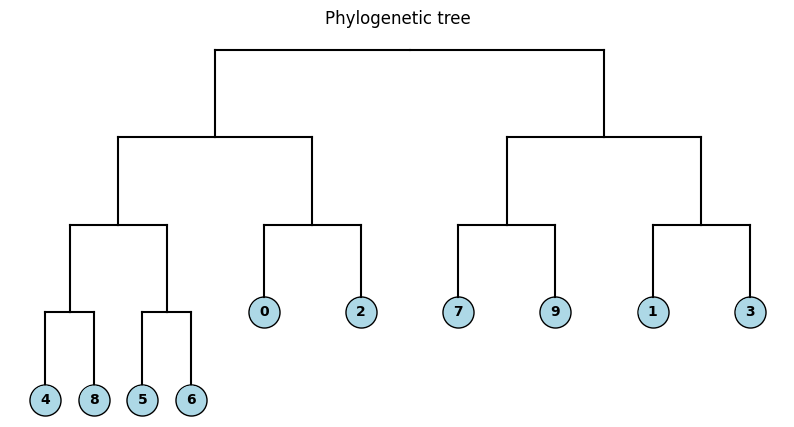

In [93]:
tree = bf_tree(matrix)
tree.display_tree()

---

# Pauli Correlation Encoding

After testing and implementing the reconstruction of phylogenetic trees using the QRAO algorithm, we'll try a QRAO variation, the Pauli Correlation Encoding. I think this is the same method, however, let's test it to see it. 

In [2]:
from itertools import combinations
def build_pauli_correlation_encoding(pauli, node_list, n, k=2):
    pauli_correlation_encoding = []
    for idx, c in enumerate(combinations(range(n), k)):
        if idx >= len(node_list):
            break
        paulis = ["I"] * n
        paulis[c[0]], paulis[c[1]] = pauli, pauli
        pauli_correlation_encoding.append(("".join(paulis)[::-1], 1))

    hamiltonian = []
    for pauli, weight in pauli_correlation_encoding:
        hamiltonian.append(SparsePauliOp.from_list([(pauli, weight)]))

    return hamiltonian

In [3]:
# matrix = np.array([[  0.,   4.,  70.,  88.,  30.,  36.,  23.,   5.,  72.,  36.],
#        [  4.,   0.,  33.,  89.,   9.,  23.,  18.,   9.,  60.,  79.],
#        [ 70.,  33.,   0.,  36.,  15., 100.,   7.,  14.,  10.,  18.],
#        [ 88.,  89.,  36.,   0.,   6.,  35.,  69.,  96.,  67.,  15.],
#        [ 30.,   9.,  15.,   6.,   0.,  66.,  54.,  45.,  77.,  49.],
#        [ 36.,  23., 100.,  35.,  66.,   0.,  93.,   3.,  75.,  84.],
#        [ 23.,  18.,   7.,  69.,  54.,  93.,   0.,   2.,  43.,   1.],
#        [  5.,   9.,  14.,  96.,  45.,   3.,   2.,   0.,   6.,  86.],
#        [ 72.,  60.,  10.,  67.,  77.,  75.,  43.,   6.,   0.,  95.],
#        [ 36.,  79.,  18.,  15.,  49.,  84.,   1.,  86.,  95.,   0.]])   

matrix = np.array( [[ 0, 92, 73, 78, 92],
                    [92,  0, 21, 49, 34],
                    [73, 21,  0, 35, 63],
                    [78, 49, 35,  0, 29],
                    [92, 34, 63, 29,  0]])

num_nodes = matrix.shape[0]

num_qubits = int(np.ceil((1 + np.sqrt(1 + (8 / 3) * num_nodes)) / 2))

list_size = num_nodes // 3
node_x = [i for i in range(list_size)]
node_y = [i for i in range(list_size, 2 * list_size)]
node_z = [i for i in range(2 * list_size, num_nodes)]

print(f"Number of qubits: {num_qubits}")
print("List 1:", node_x)
print("List 2:", node_y)
print("List 3:", node_z)

pauli_correlation_encoding_x = build_pauli_correlation_encoding(
    "X", node_x, num_qubits
)
pauli_correlation_encoding_y = build_pauli_correlation_encoding(
    "Y", node_y, num_qubits
)
pauli_correlation_encoding_z = build_pauli_correlation_encoding(
    "Z", node_z, num_qubits
)

Number of qubits: 3
List 1: [0]
List 2: [1]
List 3: [2, 3, 4]


In [31]:
def loss_func_estimator(x, ansatz, hamiltonian, estimator, matrix, c, experiment_result, alpha=None):
    """
    Loss function (eq. 12):

      L = sum_{i<j} (1/2) * d_ij * [1 - tanh(α<Πi>) * tanh(α<Πj>)]
        + β * [sum_i tanh(α<Πi>) - (n - 2c)]^2

    Args:
        x:          Ansatz parameters.
        hamiltonian: List of 3 Pauli observables from the PCE encoding.
        matrix:     NxN weight matrix (symmetric or lower-triangular).
        c:          Target cardinality — number of assets to select.
        alpha:      Sharpness of tanh. Defaults to n.
        beta:       Weight of the cardinality penalty term.
    """
    n = matrix.shape[0]
    beta = n *100
    alpha = alpha if alpha is not None else float(n)

    # ── Run estimator ──────────────────────────────────────────────────────────
    job = estimator.run([
        (ansatz, hamiltonian[0], x),
        (ansatz, hamiltonian[1], x),
        (ansatz, hamiltonian[2], x),
    ])
    result = job.result()

    node_exp_map = {}
    idx = 0
    for r in result:
        for ev in r.data.evs:
            node_exp_map[idx] = ev
            idx += 1

    # ── tanh(α <Πi>) for every node ───────────────────────────────────────────
    tanh_vals = np.array([np.tanh(alpha * node_exp_map[i]) for i in range(n)])

    # ── Normalise matrix to handle both symmetric and lower-triangular input ──
    # np.maximum picks the non-zero side regardless of convention,
    # then triu extracts each pair (i < j) exactly once.
    W = np.triu(np.maximum(matrix, matrix.T), k=1)   # shape (n, n), upper triangle

    # ── Term 1: (1/2) * d_ij * [1 - tanh_i * tanh_j] summed over i < j ──────
    tanh_outer = np.outer(tanh_vals, tanh_vals)       # (n, n)  tanh_i * tanh_j
    term1 = 0.5 * np.sum(W * (1.0 - tanh_outer))

    # ── Term 2: β * [Σ tanh_i  −  (n − 2c)]^2 ───────────────────────────────
    term2 = beta * (np.sum(tanh_vals) - (n - 2 * c)) ** 2

    loss = float(term1 + term2)

    # global experiment_result
    # print(f"Iter {len(experiment_result):4d}: loss={loss:.6f}  "
    #       f"term1={float(term1):.4f}  term2={float(term2):.4f}")
    experiment_result.append({"loss": loss, "exp_map": node_exp_map})

    return loss

In [26]:
qc = efficient_su2(num_qubits, su2_gates=["ry", "rz"], reps=2)
pm = generate_preset_pass_manager(optimization_level=3, backend=AerSimulator())
qc = pm.run(qc)

pce = []
pce.append(
    [op.apply_layout(qc.layout) for op in pauli_correlation_encoding_x]
)
pce.append(
    [op.apply_layout(qc.layout) for op in pauli_correlation_encoding_y]
)
pce.append(
    [op.apply_layout(qc.layout) for op in pauli_correlation_encoding_z]
)

In [27]:
from scipy.optimize import minimize, OptimizeResult

estimator = AerEstimator(options={
                            "backend_options": {
                                "method": "statevector",   # exact simulation — same as StatevectorEstimator
                                "device": "CPU",           # swap to "GPU" if you have a CUDA-capable card
                                "max_parallel_threads": 0, # 0 = use all available cores
                                "max_parallel_experiments":0
                            }
                        })
experiment_result = []

max_iter = 50
counter = {"i": 0}
last_x = {"value": None}
last_fun = {"value": None}

def loss_func(x):
    last_x["value"] = x.copy()
    if counter["i"] + 1 > max_iter:
        return last_fun["value"]
    counter["i"] += 1
    val = loss_func_estimator(
        x, qc, pce, estimator, matrix, c = 2, alpha= 10
    )
    last_fun["value"] = val
    return val
seed = 42
np.random.seed(seed)
initial_params = np.random.rand(qc.num_parameters)

result = minimize(
    loss_func, initial_params, method="COBYLA", options={"rhobeg": 1.0}
)

if counter["i"] >= max_iter:
    result = OptimizeResult(
        message=f"Return from COBYLA because the objective function has been evaluated {max_iter} times.",
        success=False,
        status=3,
        fun=last_fun["value"],
        x=last_x["value"],
        nfev=counter["i"],
    )

print(result)

 message: Return from COBYLA because the objective function has been evaluated 50 times.
 success: False
  status: 3
     fun: 273.4842745378391
       x: [ 1.384e+00  1.992e+00 ...  2.938e-01  5.291e-01]
    nfev: 50


In [28]:
def get_partitions(experiment_result):
    par0, par1 = set(), set()
    best_index = min(
        range(len(experiment_result)),
        key=lambda i: experiment_result[i]["loss"],
    )
    for i in experiment_result[best_index]["exp_map"]:
        if experiment_result[best_index]["exp_map"][i] >= 0:
            par0.add(i)
        else:
            par1.add(i)
    return list(par0), list(par1), best_index

def get_result(experiment_result):
    result = []
    best_index = min(
        range(len(experiment_result)),
        key=lambda i: experiment_result[i]["loss"],
    )
    for i in experiment_result[best_index]["exp_map"]:
        if experiment_result[best_index]["exp_map"][i] >= 0:
            result.append('0')
        else:
            result.append('1')
    return result


par0, par1, best_index = get_partitions(experiment_result)
print(par0, par1)
print(get_result(experiment_result))

ValueError: min() iterable argument is empty

In [46]:
def generate_circuit(matrix: np.ndarray, pm) -> list:
    num_nodes = matrix.shape[0]

    num_qubits = int(np.ceil((1 + np.sqrt(1 + (8 / 3) * num_nodes)) / 2))

    list_size = num_nodes // 3
    node_x = [i for i in range(list_size)]
    node_y = [i for i in range(list_size, 2 * list_size)]
    node_z = [i for i in range(2 * list_size, num_nodes)]

    pauli_correlation_encoding_x = build_pauli_correlation_encoding(
        "X", node_x, num_qubits
    )
    pauli_correlation_encoding_y = build_pauli_correlation_encoding(
        "Y", node_y, num_qubits
    )
    pauli_correlation_encoding_z = build_pauli_correlation_encoding(
        "Z", node_z, num_qubits
    )

    qc = efficient_su2(num_qubits, su2_gates=["ry", "rz"], reps=2)
    qc = pm.run(qc)

    pce = []
    pce.append(
        [op.apply_layout(qc.layout) for op in pauli_correlation_encoding_x]
    )
    pce.append(
        [op.apply_layout(qc.layout) for op in pauli_correlation_encoding_y]
    )
    pce.append(
        [op.apply_layout(qc.layout) for op in pauli_correlation_encoding_z]
    )

    return qc, pce

def run_pce_min_cut(matrix: np.ndarray, qc: QuantumCircuit, pce: list, estimator, c: int, seed = 42, max_iter = 50, alpha = 10):    

    counter = {"i": 0}
    last_x = {"value": None}
    last_fun = {"value": None}
    exp_rslt = []

    def loss_func(x):
        last_x["value"] = x.copy()
        if counter["i"] + 1 > max_iter:
            return last_fun["value"]
        counter["i"] += 1
        val = loss_func_estimator(
            x, qc, pce, estimator, matrix,experiment_result=exp_rslt, c = c, alpha= alpha
        )
        last_fun["value"] = val
        return val

    np.random.seed(seed)
    initial_params = np.random.rand(qc.num_parameters)
    
    result = minimize(
        loss_func, initial_params, method="COBYLA", options={"rhobeg": 1.0}
    )

    if counter["i"] >= max_iter:
        result = OptimizeResult(
            message=f"Return from COBYLA because the objective function has been evaluated {max_iter} times.",
            success=False,
            status=3,
            fun=last_fun["value"],
            x=last_x["value"],
            nfev=counter["i"],
        )
    
    result.x = get_result(exp_rslt)
    return result

    

In [47]:
estimator = AerEstimator(
    options={
                            "backend_options": {
                                "method": "statevector",   # exact simulation — same as StatevectorEstimator
                                "device": "CPU",           # swap to "GPU" if you have a CUDA-capable card
                                "max_parallel_threads": 0, # 0 = use all available cores
                                "max_parallel_experiments":0
                            }
                        }
)
qc, pce = generate_circuit(matrix,pm)
res = run_pce_min_cut(matrix,qc,pce,estimator,1)

print(res.x)
print(res.fun)

['0', '0', '0', '0', '1']
201.20696677771767


In [57]:
def pce_phylo_tree_qiskit(matrix:np.ndarray,tags=[],estimator=AerEstimator(),**kwargs):
    r"""
    Recursive function that uses QRAO to create the Phylogenetic tree using Ncut
    
    Args:
        `matrix`: The matrix defining the graph.
        `tags`: Tags defining the names of the nodes, used for recursivity. **MUST BE AN INT LIST**
    Returns:
        The `TreeNode` containing the full tree. 
    """
    ncuts = []
    
    if not tags:
        sub_mat = matrix
        tags = list(range(matrix.shape[0]))
    else:
        sub_mat = matrix[np.ix_(tags, tags)]
        
    rows = sub_mat.shape[0]
    
    var = int(np.floor(rows/2.0))+1
    pm = generate_preset_pass_manager(optimization_level=3,backend=AerSimulator())
    qc, pce = generate_circuit(sub_mat,pm)
    while not ncuts:
        
        n_graph_0 = []
        n_graph_1 = []
        
        # Run min_cut for each configuration
        for i in range(1,var):
            # print(f'Corte con {i}')
            if 'timer' in kwargs:
                start = time.time_ns()/1000000
            # Prepare the expression and run the QRAO    
            res = run_pce_min_cut(sub_mat,qc,pce,estimator,c=i)

            result = res.x
            minim = res.fun
                    
            # Time measurement
            if 'timer' in kwargs:
                end = time.time_ns()/1000000
                kwargs['timer'].update(end-start)
                
            n_graph_0.append([tags[j] for j in range(len(result)) if result[j]=='0'])
            n_graph_1.append([tags[j] for j in range(len(result)) if result[j]=='1'])        
            # print(f'\tLa division es: {n_graph_0[i-1]} | {n_graph_1[i-1]}')
            
            # print(n_cut(minim,n_graph_0[i-1],n_graph_1[i-1],matrix))
            
            if n_graph_0[i-1] and n_graph_1[i-1]:
                ncuts.append(n_cut(minim,n_graph_0[i-1],n_graph_1[i-1],matrix))
                
    
    # Get the cuts created by the minimum ncut value
    index = np.argmin(ncuts)
    # print(f'Se selecciona la separacion: {n_graph_0[index]} | {n_graph_1[index]}')
    
    node = TreeNode(tags)
    
    # Recursivity in the first graph
    if len(n_graph_0[index]) > 2:
        if 'timer' in kwargs:
            node.children.append(pce_phylo_tree_qiskit(matrix,tags=n_graph_0[index],estimator=estimator,timer=kwargs['timer']))
        else:
            node.children.append(pce_phylo_tree_qiskit(matrix,tags=n_graph_0[index],estimator=estimator,))
    else:
        leaf = TreeNode(n_graph_0[index])
        if len(n_graph_0[index]) == 2:
            leaf.children.append(TreeNode([n_graph_0[index][0]]))
            leaf.children.append(TreeNode([n_graph_0[index][1]]))
        node.children.append(leaf)
        
    # Recursivity in the first graph
    if len(n_graph_1[index]) > 2:
        if 'timer' in kwargs:
            node.children.append(pce_phylo_tree_qiskit(matrix,tags=n_graph_1[index],estimator=estimator,timer=kwargs['timer']))
        else:
            node.children.append(pce_phylo_tree_qiskit(matrix,tags=n_graph_1[index],estimator=estimator))
    else:
        leaf = TreeNode(n_graph_1[index])
        if len(n_graph_1[index]) == 2:
            leaf.children.append(TreeNode([n_graph_1[index][0]]))
            leaf.children.append(TreeNode([n_graph_1[index][1]]))
        node.children.append(leaf)
    
    return node

Tree done in 10654.1829ms


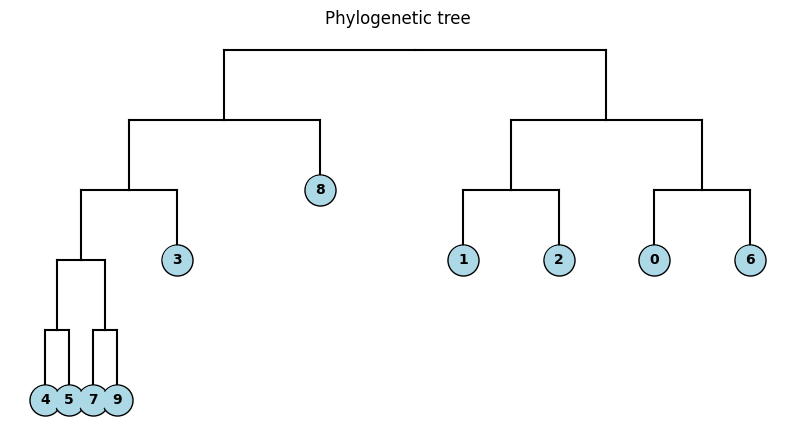

In [58]:
matrix = np.array([[  0.,   4.,  70.,  88.,  30.,  36.,  23.,   5.,  72.,  36.],
       [  4.,   0.,  33.,  89.,   9.,  23.,  18.,   9.,  60.,  79.],
       [ 70.,  33.,   0.,  36.,  15., 100.,   7.,  14.,  10.,  18.],
       [ 88.,  89.,  36.,   0.,   6.,  35.,  69.,  96.,  67.,  15.],
       [ 30.,   9.,  15.,   6.,   0.,  66.,  54.,  45.,  77.,  49.],
       [ 36.,  23., 100.,  35.,  66.,   0.,  93.,   3.,  75.,  84.],
       [ 23.,  18.,   7.,  69.,  54.,  93.,   0.,   2.,  43.,   1.],
       [  5.,   9.,  14.,  96.,  45.,   3.,   2.,   0.,   6.,  86.],
       [ 72.,  60.,  10.,  67.,  77.,  75.,  43.,   6.,   0.,  95.],
       [ 36.,  79.,  18.,  15.,  49.,  84.,   1.,  86.,  95.,   0.]])   

# matrix = np.array( [[ 0, 92, 73, 78, 92],
#                     [92,  0, 21, 49, 34],
#                     [73, 21,  0, 35, 63],
#                     [78, 49, 35,  0, 29],
#                     [92, 34, 63, 29,  0]])
estimator = AerEstimator(
    options={
                            "backend_options": {
                                "method": "statevector",   # exact simulation — same as StatevectorEstimator
                                "device": "CPU",           # swap to "GPU" if you have a CUDA-capable card
                                "max_parallel_threads": 0, # 0 = use all available cores
                                "max_parallel_experiments":0
                            }
                        }
)
timer = Timer(0.0)
tree = pce_phylo_tree_qiskit(matrix,timer=timer,estimator=estimator)
print(f"Tree done in {timer.value:.4f}ms")
tree.display_tree()

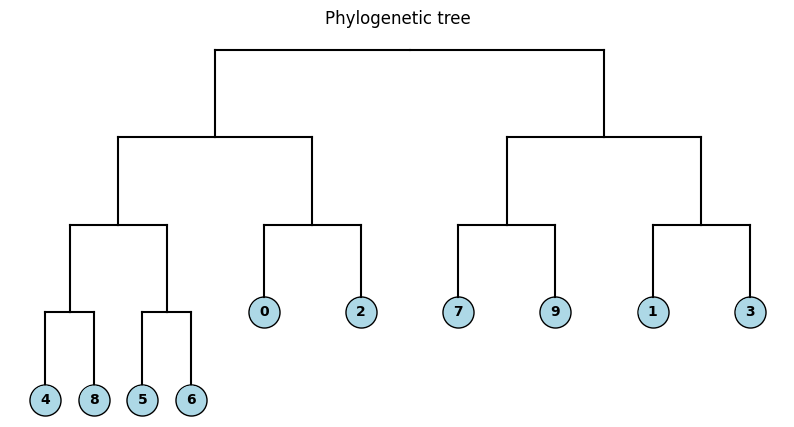

In [60]:
tree = bf_tree(matrix)
tree.display_tree()